<a href="https://colab.research.google.com/github/kamandNajari/kamandNajari/blob/main/05__Student_performance1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


In [ ]:
!ls $path

StudentsPerformance.csv


In [ ]:
data = pd.read_csv(path + '/StudentsPerformance.csv')

In [ ]:
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
data["gender"].value_counts()

,count
gender,
female,518
male,482


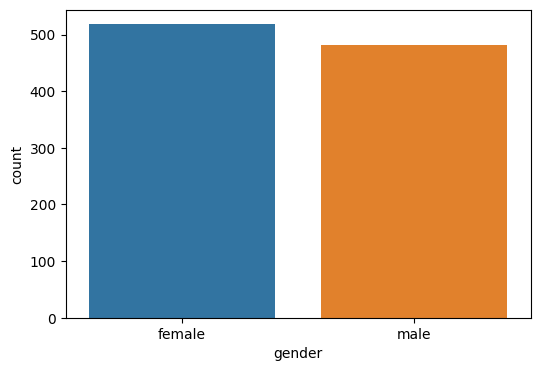

In [ ]:
fig,ax = plt.subplots(figsize=(6,4))
sns.countplot(data=data, x="gender", hue="gender")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

x = data.drop("gender", axis=1)
y = data["gender"]


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Gender classes:", label_encoder.classes_)
print("Encoded labels:", y_encoded[:10])

x.head()

Gender classes: ['female' 'male']
Encoded labels: [0 0 0 1 1 0 0 1 1 0]


,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,group B,bachelor's degree,standard,none,72,72,74
1,group C,some college,standard,completed,69,90,88
2,group B,master's degree,standard,none,90,95,93
3,group A,associate's degree,free/reduced,none,47,57,44
4,group C,some college,standard,none,76,78,75


In [ ]:
x_encoded = pd.get_dummies(x,columns=["race/ethnicity","parental level of education","lunch","test preparation course"])
x_encoded.head()

,math score,reading score,writing score,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,72,72,74,False,True,False,False,False,False,True,False,False,False,False,False,True,False,True
1,69,90,88,False,False,True,False,False,False,False,False,False,True,False,False,True,True,False
2,90,95,93,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True
3,47,57,44,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True
4,76,78,75,False,False,True,False,False,False,False,False,False,True,False,False,True,False,True


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))

x_scaled = scaler.fit_transform(x_encoded)
x_scaled[0]

array([0.72      , 0.6626506 , 0.71111111, 0.        , 1.        ,
       0.        , 0.        , 0.        , 0.        , 1.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       1.        , 0.        , 1.        ])

In [ ]:
x_scaled.shape

(1000, 18)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled,y_encoded,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 18)
(200, 18)
(800,)
(200,)


In [ ]:
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

In [ ]:
class ANN(nn.Module):

    def __init__(self):

        super(ANN,self).__init__()


        self.linear1 = nn.Linear(18, 18)
        self.tanh1 = nn.Tanh()

        self.linear2 = nn.Linear(18, 12)
        self.tanh2 = nn.Tanh()


        self.linear3 = nn.Linear(12, 2)


        self.dropout = nn.Dropout(0.2)


    def forward(self,x):

        out = self.linear1(x)
        out = self.tanh1(out)
        out = self.dropout(out)

        out = self.linear2(out)
        out = self.tanh2(out)
        out = self.dropout(out)

        out = self.linear3(out)
        return out

In [ ]:
model = ANN()

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
error = nn.CrossEntropyLoss()

In [ ]:
epochs = 500
for epoch in range(1, epochs + 1):


    optimizer.zero_grad()


    outs = model(x_train)


    loss = error(outs,y_train)


    loss.backward()


    optimizer.step()

    if epoch%25 == 0 or epoch == 1:
        print(f"Cost after iteration {epoch} is {loss:.3f}", f"Accuracy: {accuracy_score(torch.max(outs,-1)[1], y_train)*100:.1f}%")

Cost after iteration 1 is 0.700 Accuracy: 48.2%
Cost after iteration 25 is 0.693 Accuracy: 53.6%
Cost after iteration 50 is 0.684 Accuracy: 57.0%
Cost after iteration 75 is 0.662 Accuracy: 61.1%
Cost after iteration 100 is 0.649 Accuracy: 62.7%
Cost after iteration 125 is 0.610 Accuracy: 69.4%
Cost after iteration 150 is 0.581 Accuracy: 71.5%
Cost after iteration 175 is 0.531 Accuracy: 75.0%
Cost after iteration 200 is 0.475 Accuracy: 80.0%
Cost after iteration 225 is 0.417 Accuracy: 84.2%
Cost after iteration 250 is 0.358 Accuracy: 88.2%
Cost after iteration 275 is 0.321 Accuracy: 88.0%
Cost after iteration 300 is 0.298 Accuracy: 89.1%
Cost after iteration 325 is 0.275 Accuracy: 89.5%
Cost after iteration 350 is 0.262 Accuracy: 89.5%
Cost after iteration 375 is 0.251 Accuracy: 90.0%
Cost after iteration 400 is 0.247 Accuracy: 89.9%
Cost after iteration 425 is 0.247 Accuracy: 90.2%
Cost after iteration 450 is 0.242 Accuracy: 90.4%
Cost after iteration 475 is 0.231 Accuracy: 90.4%
Cost 

In [ ]:
y_head = model(x_test)
print(y_head[0])


# Converting predictions into labels
y_pred = torch.max(y_head,-1)[1]
print(y_pred[0])

print(f"Accuracy of model is {accuracy_score(y_pred, y_test)*100}%")

tensor([-0.3910,  0.5095], grad_fn=<SelectBackward0>)
tensor(1)
Accuracy of model is 91.5%
